# Modèle d'Allocation de Patients avec XGBoost
Ce notebook vise à préparer les données et à entraîner un modèle XGBoost pour allouer les patients vers le meilleur hôpital en fonction de leurs besoins en ressources et de la distance géographique.

In [29]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
import math
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import heapq
from collections import defaultdict

## 1. Chargement des données

In [30]:
# Chargement des données
df_hopitaux = pd.read_excel('Book1.xlsx')
df_patients = pd.read_excel('patients_1000_ULTRA_COMPLET.xlsx')

print('Dimensions des hôpitaux :', df_hopitaux.shape)
print('Dimensions des patients :', df_patients.shape)

Dimensions des hôpitaux : (22, 26)
Dimensions des patients : (1000, 36)


In [31]:

# Mapping des ressources (Patient -> Hôpital)
RESOURCE_MAPPINGS = {
    'Lit': {'p': 'Lits_totaux', 'h': 'Lits totaux'},
    'Rea_Lit': {'p': 'Rea_lits', 'h': 'Réa (lits)'},
    'Medecin': {'p': 'Medecins', 'h': 'Médecins'},
    'Infirmier': {'p': 'Infirmiers', 'h': 'Infirmiers'},
    'Urgentiste': {'p': 'Urgentistes', 'h': 'Urgentistes'},
    'Reanimateur': {'p': 'Reanimateurs', 'h': 'Réanimateurs'},
    'Anesth_Rea': {'p': 'Anesth_Rea', 'h': 'Anesth.-Réa'},
    'Pneumo': {'p': 'Pneumo', 'h': 'Pneumo'},
    'Cardio': {'p': 'Cardio', 'h': 'Cardio'},
    'Neuro': {'p': 'Neuro', 'h': 'Neuro'},
    'Interniste': {'p': 'Internistes', 'h': 'Internistes'},
    'Chirurgien': {'p': 'Chirurgiens', 'h': 'Chirurgiens'},
    'Pediatre': {'p': 'Pediatres', 'h': 'Pédiatres'},
    'Biologiste': {'p': 'Biologistes', 'h': 'Biologistes'},
    'Radiologue': {'p': 'Radiologues', 'h': 'Radiologues'},
    'O2': {'p': 'O2', 'h': 'O₂'},
    'Ventilateur': {'p': 'Ventilateur', 'h': 'Ventilateurs'},
    'Sang': {'p': 'Sang', 'h': 'Sang (unités)'},
    'Moniteur': {'p': 'Moniteurs', 'h': 'Moniteurs'},
    'Defibrillateur': {'p': 'Defibrillateur', 'h': 'Défibrillateurs'},
    'Monitoring': {'p': 'Monitoring', 'h': 'Moniteurs'},
    'Labo': {'p': 'Labo', 'h': 'Labo'},
    'Imagerie': {'p': 'Imagerie', 'h': 'Imagerie'}
}

RESOURCE_MAPPINGS

{'Lit': {'p': 'Lits_totaux', 'h': 'Lits totaux'},
 'Rea_Lit': {'p': 'Rea_lits', 'h': 'Réa (lits)'},
 'Medecin': {'p': 'Medecins', 'h': 'Médecins'},
 'Infirmier': {'p': 'Infirmiers', 'h': 'Infirmiers'},
 'Urgentiste': {'p': 'Urgentistes', 'h': 'Urgentistes'},
 'Reanimateur': {'p': 'Reanimateurs', 'h': 'Réanimateurs'},
 'Anesth_Rea': {'p': 'Anesth_Rea', 'h': 'Anesth.-Réa'},
 'Pneumo': {'p': 'Pneumo', 'h': 'Pneumo'},
 'Cardio': {'p': 'Cardio', 'h': 'Cardio'},
 'Neuro': {'p': 'Neuro', 'h': 'Neuro'},
 'Interniste': {'p': 'Internistes', 'h': 'Internistes'},
 'Chirurgien': {'p': 'Chirurgiens', 'h': 'Chirurgiens'},
 'Pediatre': {'p': 'Pediatres', 'h': 'Pédiatres'},
 'Biologiste': {'p': 'Biologistes', 'h': 'Biologistes'},
 'Radiologue': {'p': 'Radiologues', 'h': 'Radiologues'},
 'O2': {'p': 'O2', 'h': 'O₂'},
 'Ventilateur': {'p': 'Ventilateur', 'h': 'Ventilateurs'},
 'Sang': {'p': 'Sang', 'h': 'Sang (unités)'},
 'Moniteur': {'p': 'Moniteurs', 'h': 'Moniteurs'},
 'Defibrillateur': {'p': 'Defibri

## 2. Règles d'allocation et labels
- **Référence statique** (`Hopital_Alloue_Static`) : plus proche parmi les hôpitaux éligibles sans mise à jour des capacités (comparaison telle quelle avec `Book1`).
- **Simulation dynamique** (cellule suivante) : décrément des ressources à chaque admission, **priorité ESI** (1 en premier) et **FIFO** à ESI égal, **zone quarantaine** si aucun hôpital ne peut absorber le besoin, **réinjection** des files quand les libérations (durée de séjour) restituent les ressources. La cible ML est **`Hopital_Alloue`** issue de cette simulation.

In [32]:
# Fonction pour calculer la distance de Haversine entre deux points GPS
def haversine(lat1, lon1, lat2, lon2):
    R = 6371 # Rayon de la terre en km
    phi1 = math.radians(lat1)
    phi2 = math.radians(lat2)
    delta_phi = math.radians(lat2 - lat1)
    delta_lambda = math.radians(lon2 - lon1)
    a = math.sin(delta_phi / 2.0)**2 + math.cos(phi1) * math.cos(phi2) * math.sin(delta_lambda / 2.0)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    return R * c


In [33]:

# Nettoyage : forcer la conversion en nombre pour les comparaisons
for key, mapping in RESOURCE_MAPPINGS.items():
    col_p = mapping['p']
    col_h = mapping['h']
    if col_p in df_patients.columns:
        df_patients[col_p] = pd.to_numeric(df_patients[col_p], errors='coerce').fillna(0)
    if col_h in df_hopitaux.columns:
        df_hopitaux[col_h] = pd.to_numeric(df_hopitaux[col_h], errors='coerce').fillna(0)

def allouer_hopital(patient, df_hopitaux):
    hopitaux_eligibles = []
    
    # 1. Filtrer les hôpitaux qui ont les ressources nécessaires
    for idx, hopital in df_hopitaux.iterrows():
        est_eligible = True
        for key, mapping in RESOURCE_MAPPINGS.items():
            col_patient = mapping['p']
            col_hopital = mapping['h']
            
            # Vérification uniquement si les deux colonnes existent
            if col_patient in patient and col_hopital in hopital:
                besoin = patient[col_patient]
                capacite = hopital[col_hopital]
                
                # Conversion robuste pour éviter les erreurs de type string/int
                try:
                    besoin = float(besoin)
                except:
                    besoin = 0.0
                
                try:
                    capacite = float(capacite)
                except:
                    capacite = 0.0
                
                if besoin > 0 and capacite < besoin:
                    est_eligible = False
                    break
        
        if est_eligible:
            hopitaux_eligibles.append(hopital)
    
    # 2. Gérer le cas où aucun n'est éligible (par défaut, on assigne au plus grand hôpital)
    if not hopitaux_eligibles:
        return df_hopitaux.iloc[0]['Hôpital']
    
    # 3. Parmi les éligibles, trouver le plus proche
    distances = []
    for h in hopitaux_eligibles:
        dist = haversine(patient['Latitude'], patient['Longitude'], h['Lat'], h['Long'])
        distances.append((h['Hôpital'], dist))
        
    distances.sort(key=lambda x: x[1])
    return distances[0][0]

print("Allocation statique (référence, capacités non décrémentées)...")
df_patients['Hopital_Alloue_Static'] = df_patients.apply(
    lambda row: allouer_hopital(row, df_hopitaux), axis=1
)
print(df_patients['Hopital_Alloue_Static'].value_counts())

Allocation statique (référence, capacités non décrémentées)...
Hopital_Alloue_Static
Centre Hospitalier Universitaire Yalgado Ouédraogo    380
Centre Hospitalier Universitaire de Bogodogo          160
Hôpital Paul VI                                       148
Polyclinique Internationale de Ouagadougou             92
Centre Hospitalier Universitaire de Tingandogo         63
Centre Médical Protestant Schiphra                     52
Hôpital Saint Camille                                  39
Centre Médical Ahmadiyya                               35
Centre Médical Bethsaïda                               29
Centre Médical de Saaba                                 2
Name: count, dtype: int64


In [34]:
# --- Simulation dynamique : décrément des ressources, priorité ESI + FIFO, quarantaine, réinjection ---
QUARANTAINE_LABEL = "ZONE_QUARANTAINE"
LITS_COL = "Lits totaux"


def patient_resource_needs(patient_row):
    need_by_hcol = {}
    for mapping in RESOURCE_MAPPINGS.values():
        col_p = mapping["p"]
        col_h = mapping["h"]
        if col_p not in patient_row.index:
            continue
        v = pd.to_numeric(patient_row[col_p], errors="coerce")
        v = float(v) if pd.notna(v) else 0.0
        if v <= 0:
            continue
        need_by_hcol[col_h] = need_by_hcol.get(col_h, 0.0) + v
    return need_by_hcol


def init_remaining(df_hop):
    hcols = list(dict.fromkeys(m["h"] for m in RESOURCE_MAPPINGS.values()))
    remaining = {}
    for _, hop in df_hop.iterrows():
        name = hop["Hôpital"]
        d = {}
        for col_h in hcols:
            if col_h in hop.index:
                d[col_h] = float(pd.to_numeric(hop[col_h], errors="coerce") or 0)
            else:
                d[col_h] = 0.0
        remaining[name] = d
    return remaining


def hospital_can_serve(hname, needs, remaining):
    if not needs:
        return True
    r = remaining[hname]
    for col_h, amt in needs.items():
        if amt <= 0:
            continue
        if r.get(col_h, 0) < amt - 1e-9:
            return False
    return True


def subtract_needs(hname, needs, remaining):
    for col_h, amt in needs.items():
        if amt > 0:
            remaining[hname][col_h] = remaining[hname].get(col_h, 0) - amt


def flush_events_until(events, remaining, t_max):
    while events and events[0][0] <= t_max:
        _, hn, nd = heapq.heappop(events)
        for col_h, amt in nd.items():
            remaining[hn][col_h] = remaining[hn].get(col_h, 0) + amt


def pick_nearest_eligible(patient_row, df_hop, remaining):
    needs = patient_resource_needs(patient_row)
    cand = []
    for _, hop in df_hop.iterrows():
        hn = hop["Hôpital"]
        if hospital_can_serve(hn, needs, remaining):
            dist = haversine(
                float(patient_row["Latitude"]),
                float(patient_row["Longitude"]),
                float(hop["Lat"]),
                float(hop["Long"]),
            )
            cand.append((dist, hn))
    if not cand:
        return None
    cand.sort(key=lambda x: x[0])
    return cand[0][1]


def los_for_patient(row, rng):
    for col in ("Duree_sejour", "Duree_sejour_jours", "LOS", "jours_sejour", "duree_sejour"):
        if col in row.index and pd.notna(row[col]):
            return max(1, int(float(row[col])))
    esi = int(pd.to_numeric(row.get("ESI", 3), errors="coerce") or 3)
    esi = max(1, min(5, esi))
    base = max(1, 7 - esi)
    return int(base + rng.integers(0, 5))


def flush_quarantine_queue(queue, df_hop, remaining, events, current_t, results, rng):
    changed = True
    while changed:
        changed = False
        queue.sort(key=lambda x: (x["esi"], x["fifo"]))
        kept = []
        for item in queue:
            row = item["row"]
            hn = pick_nearest_eligible(row, df_hop, remaining)
            if hn is not None:
                needs = patient_resource_needs(row)
                los = los_for_patient(row, rng)
                subtract_needs(hn, needs, remaining)
                snap = {k: float(v) for k, v in needs.items() if v > 0}
                heapq.heappush(events, (current_t + los, hn, snap))
                results[item["idx"]] = hn
                changed = True
            else:
                kept.append(item)
        queue = kept
    return queue


def run_dynamic_simulation(df_patients, df_hopitaux, random_seed=42):
    rng = np.random.default_rng(random_seed)
    remaining = init_remaining(df_hopitaux)
    events = []
    queue = []
    results = {}
    history = []

    work = df_patients.copy()
    work["_fifo_arrival"] = np.arange(len(work))
    work["_esi"] = pd.to_numeric(work["ESI"], errors="coerce").fillna(5).astype(int).clip(1, 5)
    work = work.sort_values(["_esi", "_fifo_arrival"], kind="mergesort")

    caps_lit = {
        hop["Hôpital"]: float(pd.to_numeric(hop.get(LITS_COL, 0), errors="coerce") or 0)
        for _, hop in df_hopitaux.iterrows()
    }

    for t, (orig_idx, prow) in enumerate(work.iterrows()):
        flush_events_until(events, remaining, t)

        hn = pick_nearest_eligible(prow, df_hopitaux, remaining)
        if hn is not None:
            needs = patient_resource_needs(prow)
            los = los_for_patient(prow, rng)
            subtract_needs(hn, needs, remaining)
            snap = {k: float(v) for k, v in needs.items() if v > 0}
            heapq.heappush(events, (t + los, hn, snap))
            results[orig_idx] = hn
        else:
            queue.append(
                {
                    "idx": orig_idx,
                    "esi": int(prow["_esi"]),
                    "fifo": int(prow["_fifo_arrival"]),
                    "row": prow,
                }
            )

        queue = flush_quarantine_queue(queue, df_hopitaux, remaining, events, t, results, rng)

        occ_lit = {}
        for hname, cap in caps_lit.items():
            rem = remaining[hname].get(LITS_COL, 0)
            if cap > 0:
                occ_lit[hname] = max(0.0, cap - rem) / cap
            else:
                occ_lit[hname] = 0.0
        history.append({"t": t, "queue_len": len(queue), "occ_lit": occ_lit.copy()})

    flush_events_until(events, remaining, float("inf"))

    for item in queue:
        results[item["idx"]] = QUARANTAINE_LABEL

    return results, history


results_dyn, simulation_history = run_dynamic_simulation(df_patients, df_hopitaux)
df_patients["Hopital_Alloue"] = df_patients.index.map(results_dyn).fillna(QUARANTAINE_LABEL)

print("Allocation dynamique :")
print(df_patients["Hopital_Alloue"].value_counts())
n_q = (df_patients["Hopital_Alloue"] == QUARANTAINE_LABEL).sum()
print("Patients en ZONE_QUARANTAINE :", int(n_q))

TypeError: '<' not supported between instances of 'dict' and 'dict'

## 3. Préparation des données pour XGBoost
La cible est **`Hopital_Alloue`** (simulation dynamique), incluant éventuellement **`ZONE_QUARANTAINE`**. Les features restent identiques (dont **ESI** comme covariable, pas comme seul tri — le tri opérationnel est dans la simulation).

In [ ]:
# Sélection des features (X)
# On prend les données vitales, l'urgence, les coordonnées géographiques
features_cols = ['ESI', 'SpO2', 'FC', 'FR', 'GCS', 'Latitude', 'Longitude'] 


ressources_cols = [v['p'] for k, v in RESOURCE_MAPPINGS.items() if v['p'] in df_patients.columns]
features_cols.extend(ressources_cols)

# Retirer les doublons potentiels
features_cols = list(set(features_cols))

X = df_patients[features_cols].copy()

X = X.fillna(0)

# Encodage de la Target (y)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df_patients['Hopital_Alloue'])

print("Shape de X :", X.shape)
print("Classes cibles (Hôpitaux) :", label_encoder.classes_)

Shape de X : (1000, 30)
Classes cibles (Hôpitaux) : ['Centre Hospitalier Universitaire Yalgado Ouédraogo'
 'Centre Hospitalier Universitaire de Bogodogo'
 'Centre Hospitalier Universitaire de Tingandogo'
 'Centre Médical Ahmadiyya' 'Centre Médical Bethsaïda'
 'Centre Médical Protestant Schiphra' 'Centre Médical de Saaba'
 'Hôpital Paul VI' 'Hôpital Saint Camille'
 'Polyclinique Internationale de Ouagadougou']


## 4. Entraînement du modèle XGBoost

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialisation du modèle
model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(label_encoder.classes_),
    eval_metric='mlogloss',
    random_state=42
)

model.fit(X_train, y_train)

,objective,'multi:softmax'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


## 5. Évaluation du modèle
Vérifions les performances globales du modèle sur les données de test.

Précision (Accuracy) : 96.50%

Rapport de classification :
                                                    precision    recall  f1-score   support

Centre Hospitalier Universitaire Yalgado Ouédraogo       0.97      0.97      0.97        79
      Centre Hospitalier Universitaire de Bogodogo       0.97      0.97      0.97        32
    Centre Hospitalier Universitaire de Tingandogo       1.00      1.00      1.00        16
                          Centre Médical Ahmadiyya       1.00      1.00      1.00         5
                          Centre Médical Bethsaïda       1.00      0.91      0.95        11
                Centre Médical Protestant Schiphra       0.89      0.80      0.84        10
                                   Hôpital Paul VI       0.93      1.00      0.97        28
                             Hôpital Saint Camille       1.00      0.80      0.89         5
        Polyclinique Internationale de Ouagadougou       0.93      1.00      0.97        14

                   

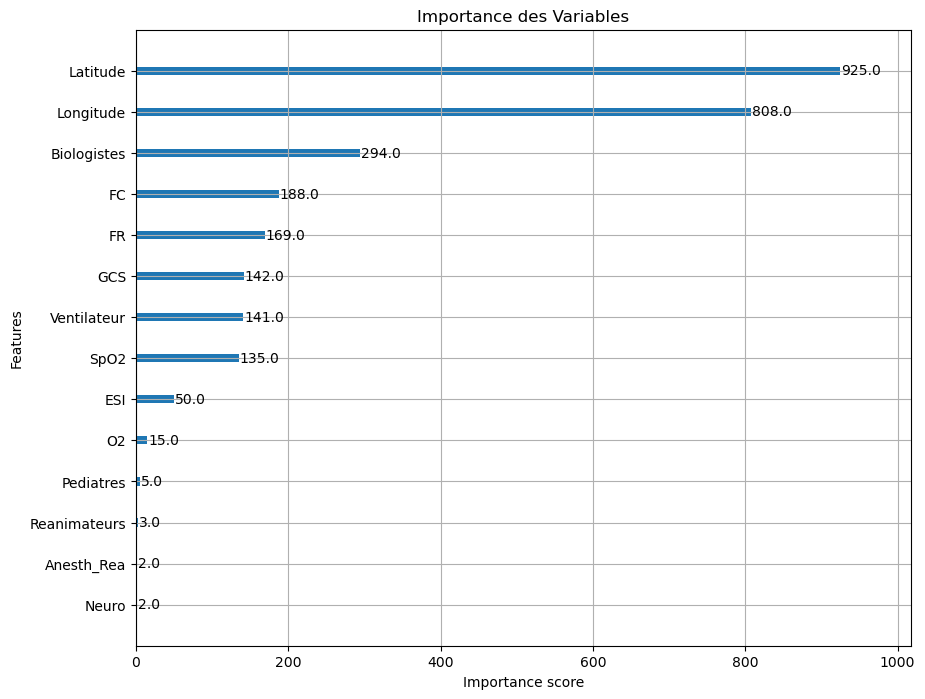

In [ ]:
# Prédictions sur l'ensemble de test
y_pred = model.predict(X_test)

# Calcul de la précision
accuracy = accuracy_score(y_test, y_pred)
print(f"Précision (Accuracy) : {accuracy * 100:.2f}%\n")

# Rapport détaillé
noms_classes = [str(c) for c in label_encoder.classes_]

# On gère le cas où certaines classes ne seraient pas dans le test set
classes_in_test = np.unique(y_test)
target_names = [noms_classes[i] for i in classes_in_test]

print("Rapport de classification :")
print(classification_report(y_test, y_pred, target_names=target_names))

# Visualisation des variables les plus importantes pour les décisions de l'IA
fig, ax = plt.subplots(figsize=(10, 8))
xgb.plot_importance(model, max_num_features=15, ax=ax, title="Importance des Variables")
plt.show()

## 6. Synthèse : ce qui est implémenté dans ce notebook

- **Capacités dynamiques** : à chaque admission, toutes les ressources du mapping `RESOURCE_MAPPINGS` sont décrémentées ; elles sont **restituées** à la date `t + LOS` (durée de séjour).
- **Priorité ESI + FIFO** : ordre de traitement = **ESI croissant** (1 en premier), puis **ordre d’arrivée** dans le jeu de données pour un même ESI.
- **Zone quarantaine** : label **`ZONE_QUARANTAINE`** si, au moment traité, aucun hôpital n’a les ressources disponibles ; **réinjection** : après chaque arrivée, la file est vidée tant que des places se libèrent (multi-passes), toujours en respectant ESI puis FIFO.
- **LOS** : colonnes `Duree_sejour`, `LOS`, etc. si présentes ; sinon LOS **synthétique** dérivée de l’ESI (`los_for_patient`). Pour une réinjection calendaire réaliste, enrichir avec une vraie durée de séjour ou des horodatages.
- **Référence** : `Hopital_Alloue_Static` conserve l’ancienne règle sans décrément (comparaison possible).

---

## 7. Graphiques — simulation, performance du modèle et gestion des patients

File d’attente et **taux d’occupation des lits** (simulation), matrices de confusion, métriques par destination (dont quarantaine), faisabilité statique en ressources, accuracy par ESI.

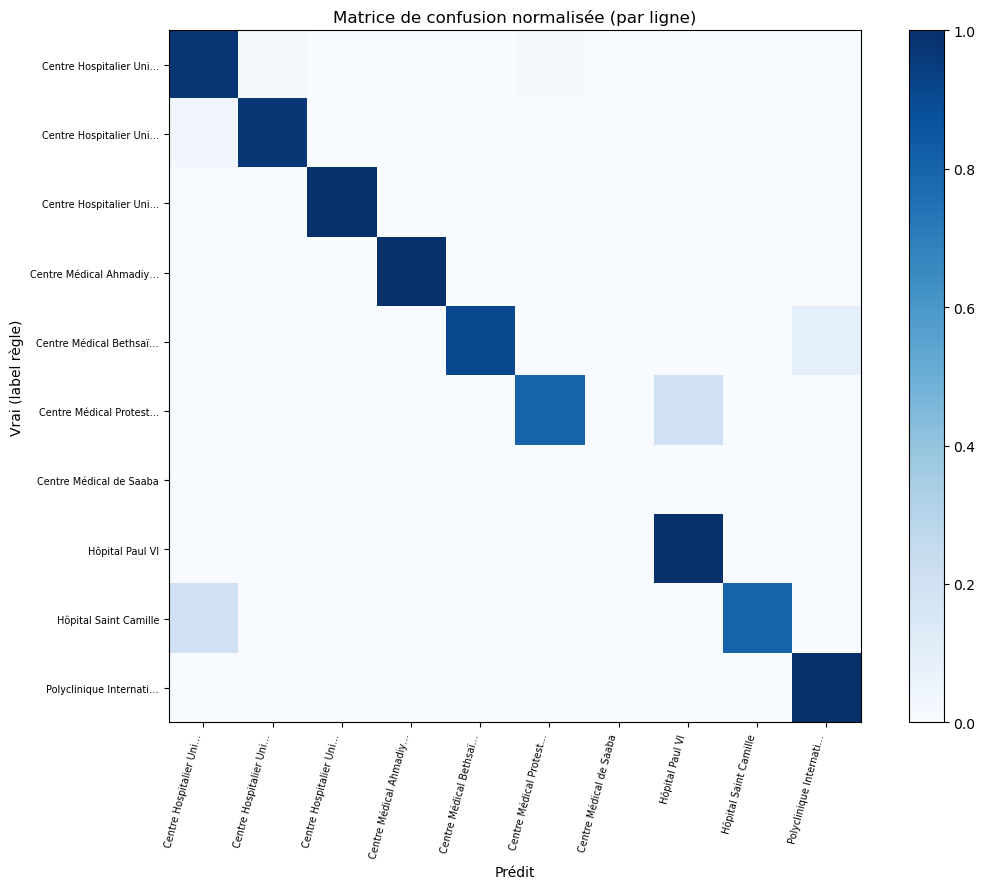

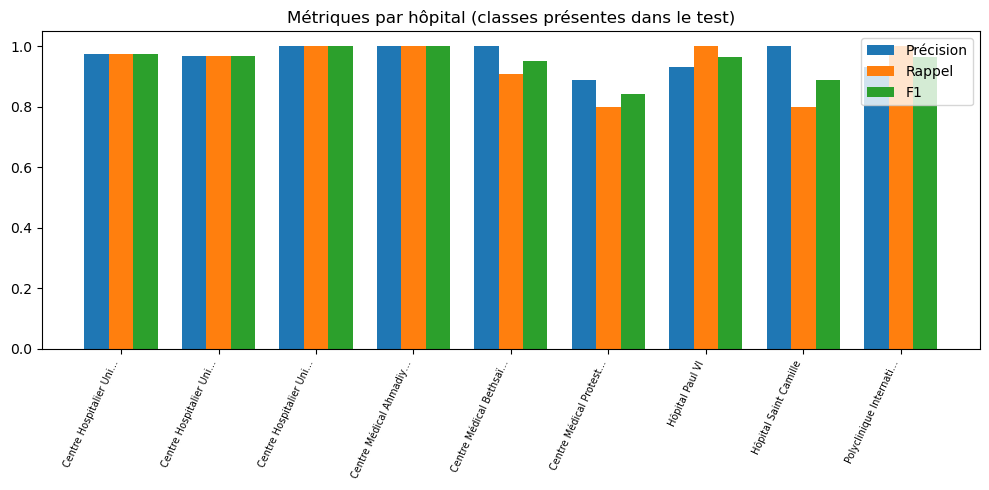

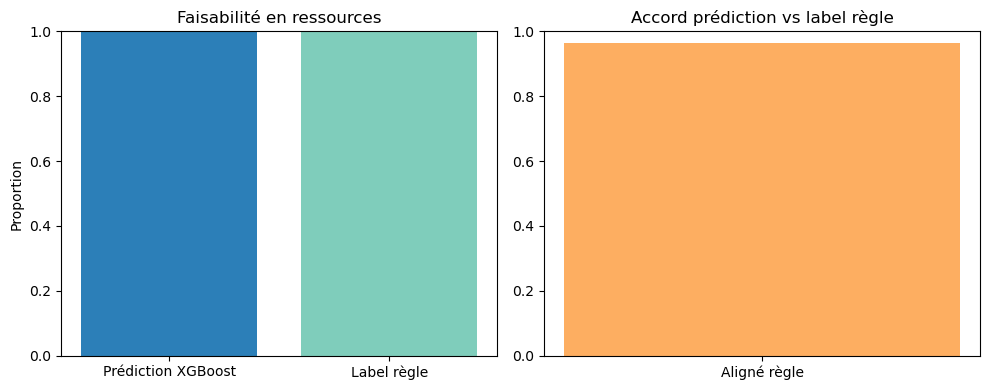

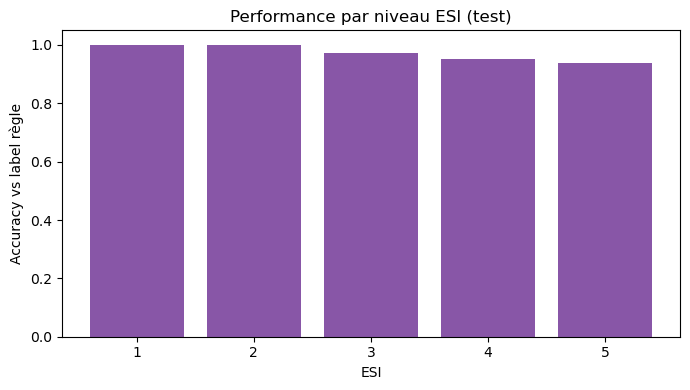

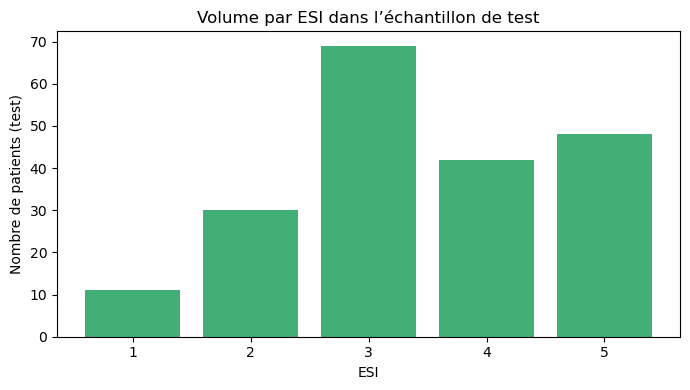

Prédictions réalisables en ressources : 100.0%
Labels règle réalisables : 100.0%
Sans FIFO ni occupation dynamique des lits, les graphiques ci-dessus ne modélisent pas la zone de quarantaine du schéma.


In [ ]:
def patient_eligible_hopital_row(patient_row, hop_row):
    """Aligné sur la logique de `allouer_hopital` pour une ligne hôpital donnée."""
    for key, mapping in RESOURCE_MAPPINGS.items():
        col_patient = mapping["p"]
        col_hopital = mapping["h"]
        if col_patient not in patient_row.index or col_hopital not in hop_row.index:
            continue
        besoin = pd.to_numeric(patient_row[col_patient], errors="coerce")
        capacite = pd.to_numeric(hop_row[col_hopital], errors="coerce")
        besoin = float(besoin) if pd.notna(besoin) else 0.0
        capacite = float(capacite) if pd.notna(capacite) else 0.0
        if besoin > 0 and capacite < besoin:
            return False
    return True


def hopital_row_by_name(name):
    m = df_hopitaux[df_hopitaux["Hôpital"] == name]
    return None if m.empty else m.iloc[0]


QUARANT_LABEL = globals().get("QUARANTAINE_LABEL", "ZONE_QUARANTAINE")


def resource_feasibility_for_label(name, prow):
    """Quarantaine : état d'attente dynamique (pas une ligne hôpital Book1). Sinon faisabilité vs capacités statiques."""
    if name == QUARANT_LABEL:
        return True
    hrow = hopital_row_by_name(name)
    return hrow is not None and patient_eligible_hopital_row(prow, hrow)


test_indices = X_test.index
df_eval = df_patients.loc[test_indices].copy()
y_true_lab = label_encoder.inverse_transform(y_test)
y_pred_lab = label_encoder.inverse_transform(y_pred)

labels_ord = np.arange(len(label_encoder.classes_))
cm = confusion_matrix(y_test, y_pred, labels=labels_ord)
with np.errstate(divide="ignore", invalid="ignore"):
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
cm_norm = np.nan_to_num(cm_norm)

abbrev = [str(c)[:22] + "…" if len(str(c)) > 23 else str(c) for c in label_encoder.classes_]

fig1, ax1 = plt.subplots(figsize=(11, 9))
im = ax1.imshow(cm_norm, vmin=0, vmax=1, cmap="Blues")
ax1.set_xticks(range(len(abbrev)))
ax1.set_yticks(range(len(abbrev)))
ax1.set_xticklabels(abbrev, rotation=75, ha="right", fontsize=7)
ax1.set_yticklabels(abbrev, fontsize=7)
ax1.set_xlabel("Prédit")
ax1.set_ylabel("Vrai (label règle)")
ax1.set_title("Matrice de confusion normalisée (par ligne)")
plt.colorbar(im, ax=ax1, fraction=0.046)
plt.tight_layout()
plt.show()

prec, rec, f1, sup = precision_recall_fscore_support(
    y_test, y_pred, labels=labels_ord, zero_division=0
)
mask = sup > 0
fig2, ax2 = plt.subplots(figsize=(10, 5))
xpos = np.arange(mask.sum())
w = 0.25
ax2.bar(xpos - w, prec[mask], width=w, label="Précision")
ax2.bar(xpos, rec[mask], width=w, label="Rappel")
ax2.bar(xpos + w, f1[mask], width=w, label="F1")
ax2.set_xticks(xpos)
ax2.set_xticklabels([abbrev[i] for i in np.where(mask)[0]], rotation=65, ha="right", fontsize=7)
ax2.set_ylim(0, 1.05)
ax2.legend()
ax2.set_title("Métriques par hôpital (classes présentes dans le test)")
plt.tight_layout()
plt.show()

pred_ok = np.array(
    [resource_feasibility_for_label(y_pred_lab[i], df_eval.iloc[i]) for i in range(len(df_eval))]
)
rule_ok = np.array(
    [resource_feasibility_for_label(y_true_lab[i], df_eval.iloc[i]) for i in range(len(df_eval))]
)
mask_pred_hosp = y_pred_lab != QUARANT_LABEL
mask_true_hosp = y_true_lab != QUARANT_LABEL
pred_ok_hospitals_only = pred_ok[mask_pred_hosp]
rule_ok_hospitals_only = rule_ok[mask_true_hosp]

fig3, axes3 = plt.subplots(1, 2, figsize=(10, 4))
axes3[0].bar(
    ["Prédiction XGBoost", "Label règle"],
    [pred_ok.mean(), rule_ok.mean()],
    color=["#2c7fb8", "#7fcdbb"],
)
axes3[0].set_ylim(0, 1)
axes3[0].set_title("Faisabilité (quarantaine OK ou Book1)")
axes3[0].set_ylabel("Proportion")
axes3[1].bar(["Aligné règle"], [(y_pred_lab == y_true_lab).mean()], color="#fdae61")
axes3[1].set_ylim(0, 1)
axes3[1].set_title("Accord prédiction vs label règle")
plt.tight_layout()
plt.show()

if "ESI" in df_eval.columns:
    esi_vals = pd.to_numeric(df_eval["ESI"], errors="coerce").fillna(0).astype(int)
    order = sorted(esi_vals.unique())
    acc_by_esi = []
    for e in order:
        m = esi_vals.values == e
        acc_by_esi.append(accuracy_score(y_test[m], y_pred[m]) if m.sum() else 0.0)
    fig4, ax4 = plt.subplots(figsize=(7, 4))
    ax4.bar([str(e) for e in order], acc_by_esi, color="#8856a7")
    ax4.set_ylim(0, 1.05)
    ax4.set_xlabel("ESI")
    ax4.set_ylabel("Accuracy vs label règle")
    ax4.set_title("Performance par niveau ESI (test)")
    plt.tight_layout()
    plt.show()

by_esi_counts = (
    df_eval.assign(_esi=pd.to_numeric(df_eval.get("ESI", 0), errors="coerce").fillna(0).astype(int))
    .groupby("_esi")
    .size()
)
fig5, ax5 = plt.subplots(figsize=(7, 4))
ax5.bar(by_esi_counts.index.astype(str), by_esi_counts.values, color="#41ae76")
ax5.set_xlabel("ESI")
ax5.set_ylabel("Nombre de patients (test)")
ax5.set_title("Volume par ESI dans le jeu de test")
plt.tight_layout()
plt.show()

hist = globals().get("simulation_history")
if hist:
    ts = [row["t"] for row in hist]
    ql = [row["queue_len"] for row in hist]
    all_names = sorted({k for row in hist for k in row["occ_lit"].keys()})
    mean_occ = {hn: float(np.mean([row["occ_lit"].get(hn, 0.0) for row in hist])) for hn in all_names}
    top_h = sorted(all_names, key=lambda h: mean_occ[h], reverse=True)[:12]

    fig6, axes6 = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
    axes6[0].plot(ts, ql, color="#ca0020", lw=1.2)
    axes6[0].set_ylabel("Patients en file")
    axes6[0].set_title("Simulation dynamique — taille de la file (quarantaine)")
    for hn in top_h:
        axes6[1].plot(
            ts,
            [row["occ_lit"].get(hn, 0.0) for row in hist],
            lw=1.0,
            label=str(hn)[:26],
        )
    axes6[1].set_ylabel("Occupation lits (vs capacité initiale)")
    axes6[1].set_xlabel("t (pas = ordre d'arrivée après tri ESI / FIFO)")
    axes6[1].set_title("Occupation relative — hôpitaux les plus chargés en moyenne")
    axes6[1].legend(fontsize=6, ncol=2, loc="upper right")
    plt.tight_layout()
    plt.show()

print(f"Prédictions réalisables (quarantaine OK ou ressources Book1) : {pred_ok.mean()*100:.1f}%")
print(f"Labels règle réalisables : {rule_ok.mean()*100:.1f}%")
if mask_pred_hosp.any():
    print(
        f"  Prédictions vers un hôpital — faisabilité Book1 : {pred_ok_hospitals_only.mean()*100:.1f}% ({int(mask_pred_hosp.sum())} cas)"
    )
if mask_true_hosp.any():
    print(
        f"  Labels hôpital — faisabilité Book1 : {rule_ok_hospitals_only.mean()*100:.1f}% ({int(mask_true_hosp.sum())} cas)"
    )
print(f"Part ZONE_QUARANTAINE dans vérités (test) : {(y_true_lab == QUARANT_LABEL).mean()*100:.1f}%")
print(f"Part ZONE_QUARANTAINE dans prédictions (test) : {(y_pred_lab == QUARANT_LABEL).mean()*100:.1f}%")
if "Hopital_Alloue_Static" in df_patients.columns:
    static_lab = df_patients.loc[test_indices, "Hopital_Alloue_Static"].values
    print(
        f"Accord label dynamique vs Hopital_Alloue_Static (test) : {(static_lab == y_true_lab).mean()*100:.1f}%"
    )
print(
    "Courbes file / occupation : voir graphiques simulation si la cellule dynamique a été exécutée."
)
